In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.ops.indexing import Vindex
from pyro import poutine

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [4]:
def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [5]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [6]:
@config_enumerate
def model(data, struct_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    struct_params = {}
    # dimension: number of mixture
    struct_params["alpha0"] = pyro.param("model_alpha0", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    # dimension: number of mixture
    struct_params["alpha1"] = pyro.param("model_alpha1", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    
    for i in range(2, len(struct_upbd)+1, 1):
        # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
        struct_params[f"alpha{i}"] = pyro.param(f"model_alpha{i}", torch.rand(param_dims[-i:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-i:])
    # dimension: number of mixture * vocabulary size
    gen_params = pyro.param("model_phi_u", torch.distributions.Dirichlet(torch.ones(vocab_size, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.simplex)
    # dimension: number of mixture * 1
    reg_params_mu = pyro.param("model_phi_y_mu", torch.distributions.Normal(loc = torch.tensor(0.0, device=device), scale = torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )))
    # dimension: number of mixture * 1
    reg_params_sigma = pyro.param("model_phi_y_sigma", torch.distributions.Uniform(torch.tensor(1e-3, device=device), torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.positive)

    struct_weights = {}
    # dimension: number of mixture
    beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
    # dimension: number of mixture
    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    for level in range(1, len(struct_upbd), 1):
        struct_weights["G0"] = struct_weights["G0"].flatten()
        # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
        param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
        # print(struct_params[f"alpha{level}"].shape, struct_weights[f"G{level-1}"].shape)
        # print(f"level {level}, alpha shape {param_alpha.shape}")

        param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        # print(f"next level {beta.shape}")
        struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

    assign_prior = {}
    # dimension: number of level - 1
    etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
    for level in range(1, len(struct_upbd), 1):
        params_shape = param_dims[-level-1:-1]
        params_shape.reverse()
        # dimension: level 1 category * level 2 category * ... * level level category
        assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

    feature = data[0].to(device)
    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    assigned_zs = [torch.tensor([0], device=device).expand(N)]
    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            parent_z = assigned_zs[-1]
            param = assign_prior[f"LoZ{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)}"][assigned_zs[:-1]]

        topic_dist = pyro.sample("g", dist.Dirichlet(concentrate*weights_prior))
        reg_dists = dist.Normal(reg_params_mu.expand(N, struct_upbd["G0"]), reg_params_sigma.expand(N, struct_upbd["G0"]))
        reg_mix = dist.Categorical(topic_dist)
        pyro.sample("y", dist.MixtureSameFamily(reg_mix, reg_dists), obs=label)
        # print("topic", topic_dist.shape)

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        # print(z.shape)

        # Sample observed words from selected topics
        word_dists = gen_params[z]  # shape: (D, N, V)
        # print(word_dists.shape)
        pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

In [7]:
def guide(data, struc_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_alpha = pyro.param("guide_beta_0_alpha", init, constraint=constraints.positive)
    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_beta = pyro.param("guide_beta_0_beta", init, constraint=constraints.positive)
    beta_0 = pyro.sample("G0", dist.Beta(q_beta_0_alpha, q_beta_0_beta).to_event(1))
    for level in range(1, len(struct_upbd), 1):
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_alpha = pyro.param(f"guide_beta_{level}_alpha", init, constraint=constraints.positive)
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_beta = pyro.param(f"guide_beta_{level}_beta", init, constraint=constraints.positive)
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        
    feature = data[0].to(device)
    if (data[1] is not None):
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    # Guide only for the continuous latent variable: g
    # Variational parameters for Dirichlet over topic_dist
    g_concentration = pyro.param("guide_g_concentration", torch.ones((N, struct_upbd["G0"]), device=device),
                                 constraint=constraints.positive)

    
    with pyro.plate("Data", N):
        # for level in range(1, len(struct_upbd), 1):
        #     z_param = pyro.param(f"z_param{level}", torch.rand((N, struct_upbd[f"G{level}"]), device=device), constraint=constraints.simplex)
        #     pyro.sample(f"z{level}", dist.Categorical(z_param))
        pyro.sample("g", dist.Dirichlet(g_concentration))


In [8]:
def set_requires_grad_by_prefix(prefix, requires_grad):
    for name, param in pyro.get_param_store().items():
        if name.startswith(prefix) and param.is_leaf:
            param.requires_grad = requires_grad

In [9]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=30, V=100,  # N_per_base: number of samples per base category
    seed=0
):
    torch.manual_seed(seed)

    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_components = struct_upbd["G0"]

    total_super = num_super
    total_base = num_super * num_base_per_super
    total_data = total_base * N_per_base

    # Shared components
    word_dists = torch.distributions.Dirichlet(0.01 * torch.ones(V)).sample((num_components,))
    y_means = torch.linspace(-3, 3, steps=num_components)
    y_stds = 0.1 + 0.1 * torch.rand(num_components)

    # Create per-base-category mixture weights over the 10 shared components
    base_mixture_weights = torch.distributions.Dirichlet(0.7 * torch.ones(num_components)).sample()
    super_mixture_weights = torch.distributions.Dirichlet(2*base_mixture_weights).sample((num_super,))
    child_mixture_weights = torch.distributions.Dirichlet(10*super_mixture_weights).sample((num_base_per_super,))
    

    x_data = torch.zeros((total_data, M, V))
    y_data = torch.zeros(total_data)
    labels_super = torch.zeros(total_data, dtype=torch.long)
    labels_base = torch.zeros(total_data, dtype=torch.long)

    idx = 0
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            weights = child_mixture_weights[base_offset, super_id]

            for _ in range(N_per_base):
                # Choose a component based on mixture weights
                comp_id = torch.multinomial(weights, 1).item()

                # Generate bag-of-words document
                word_ids = torch.multinomial(word_dists[comp_id], M, replacement=True)
                x_data[idx] = F.one_hot(word_ids, num_classes=V).float()

                # Generate regression label
                y_data[idx] = torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,))

                labels_super[idx] = super_id
                labels_base[idx] = base_id
                idx += 1

    return {
        "x": x_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_mixture_weights,
        "child_mix_weights": child_mixture_weights     # (num_super*num_base_per_super, 
        
    }


In [10]:
struct_upbd = {"G0": 30, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data(struct_upbd)
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(dim=1)
vocab_size = data["x"].shape[-1]

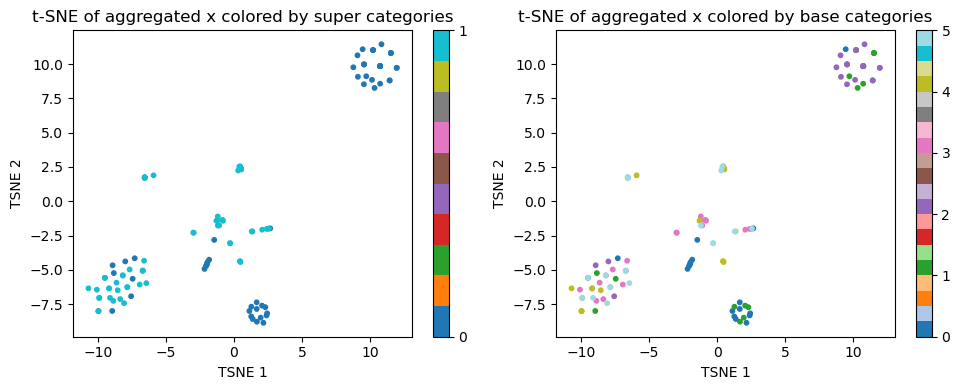

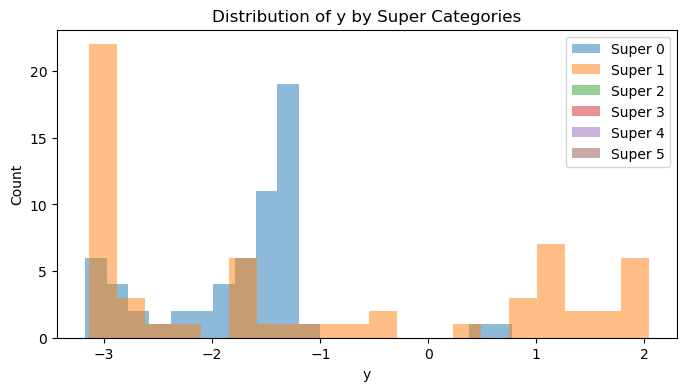

In [11]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(6):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


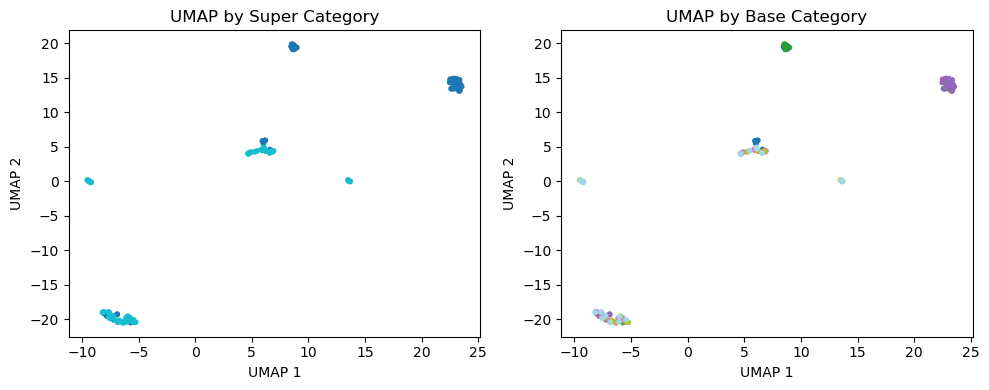

torch.Size([3, 2, 30])


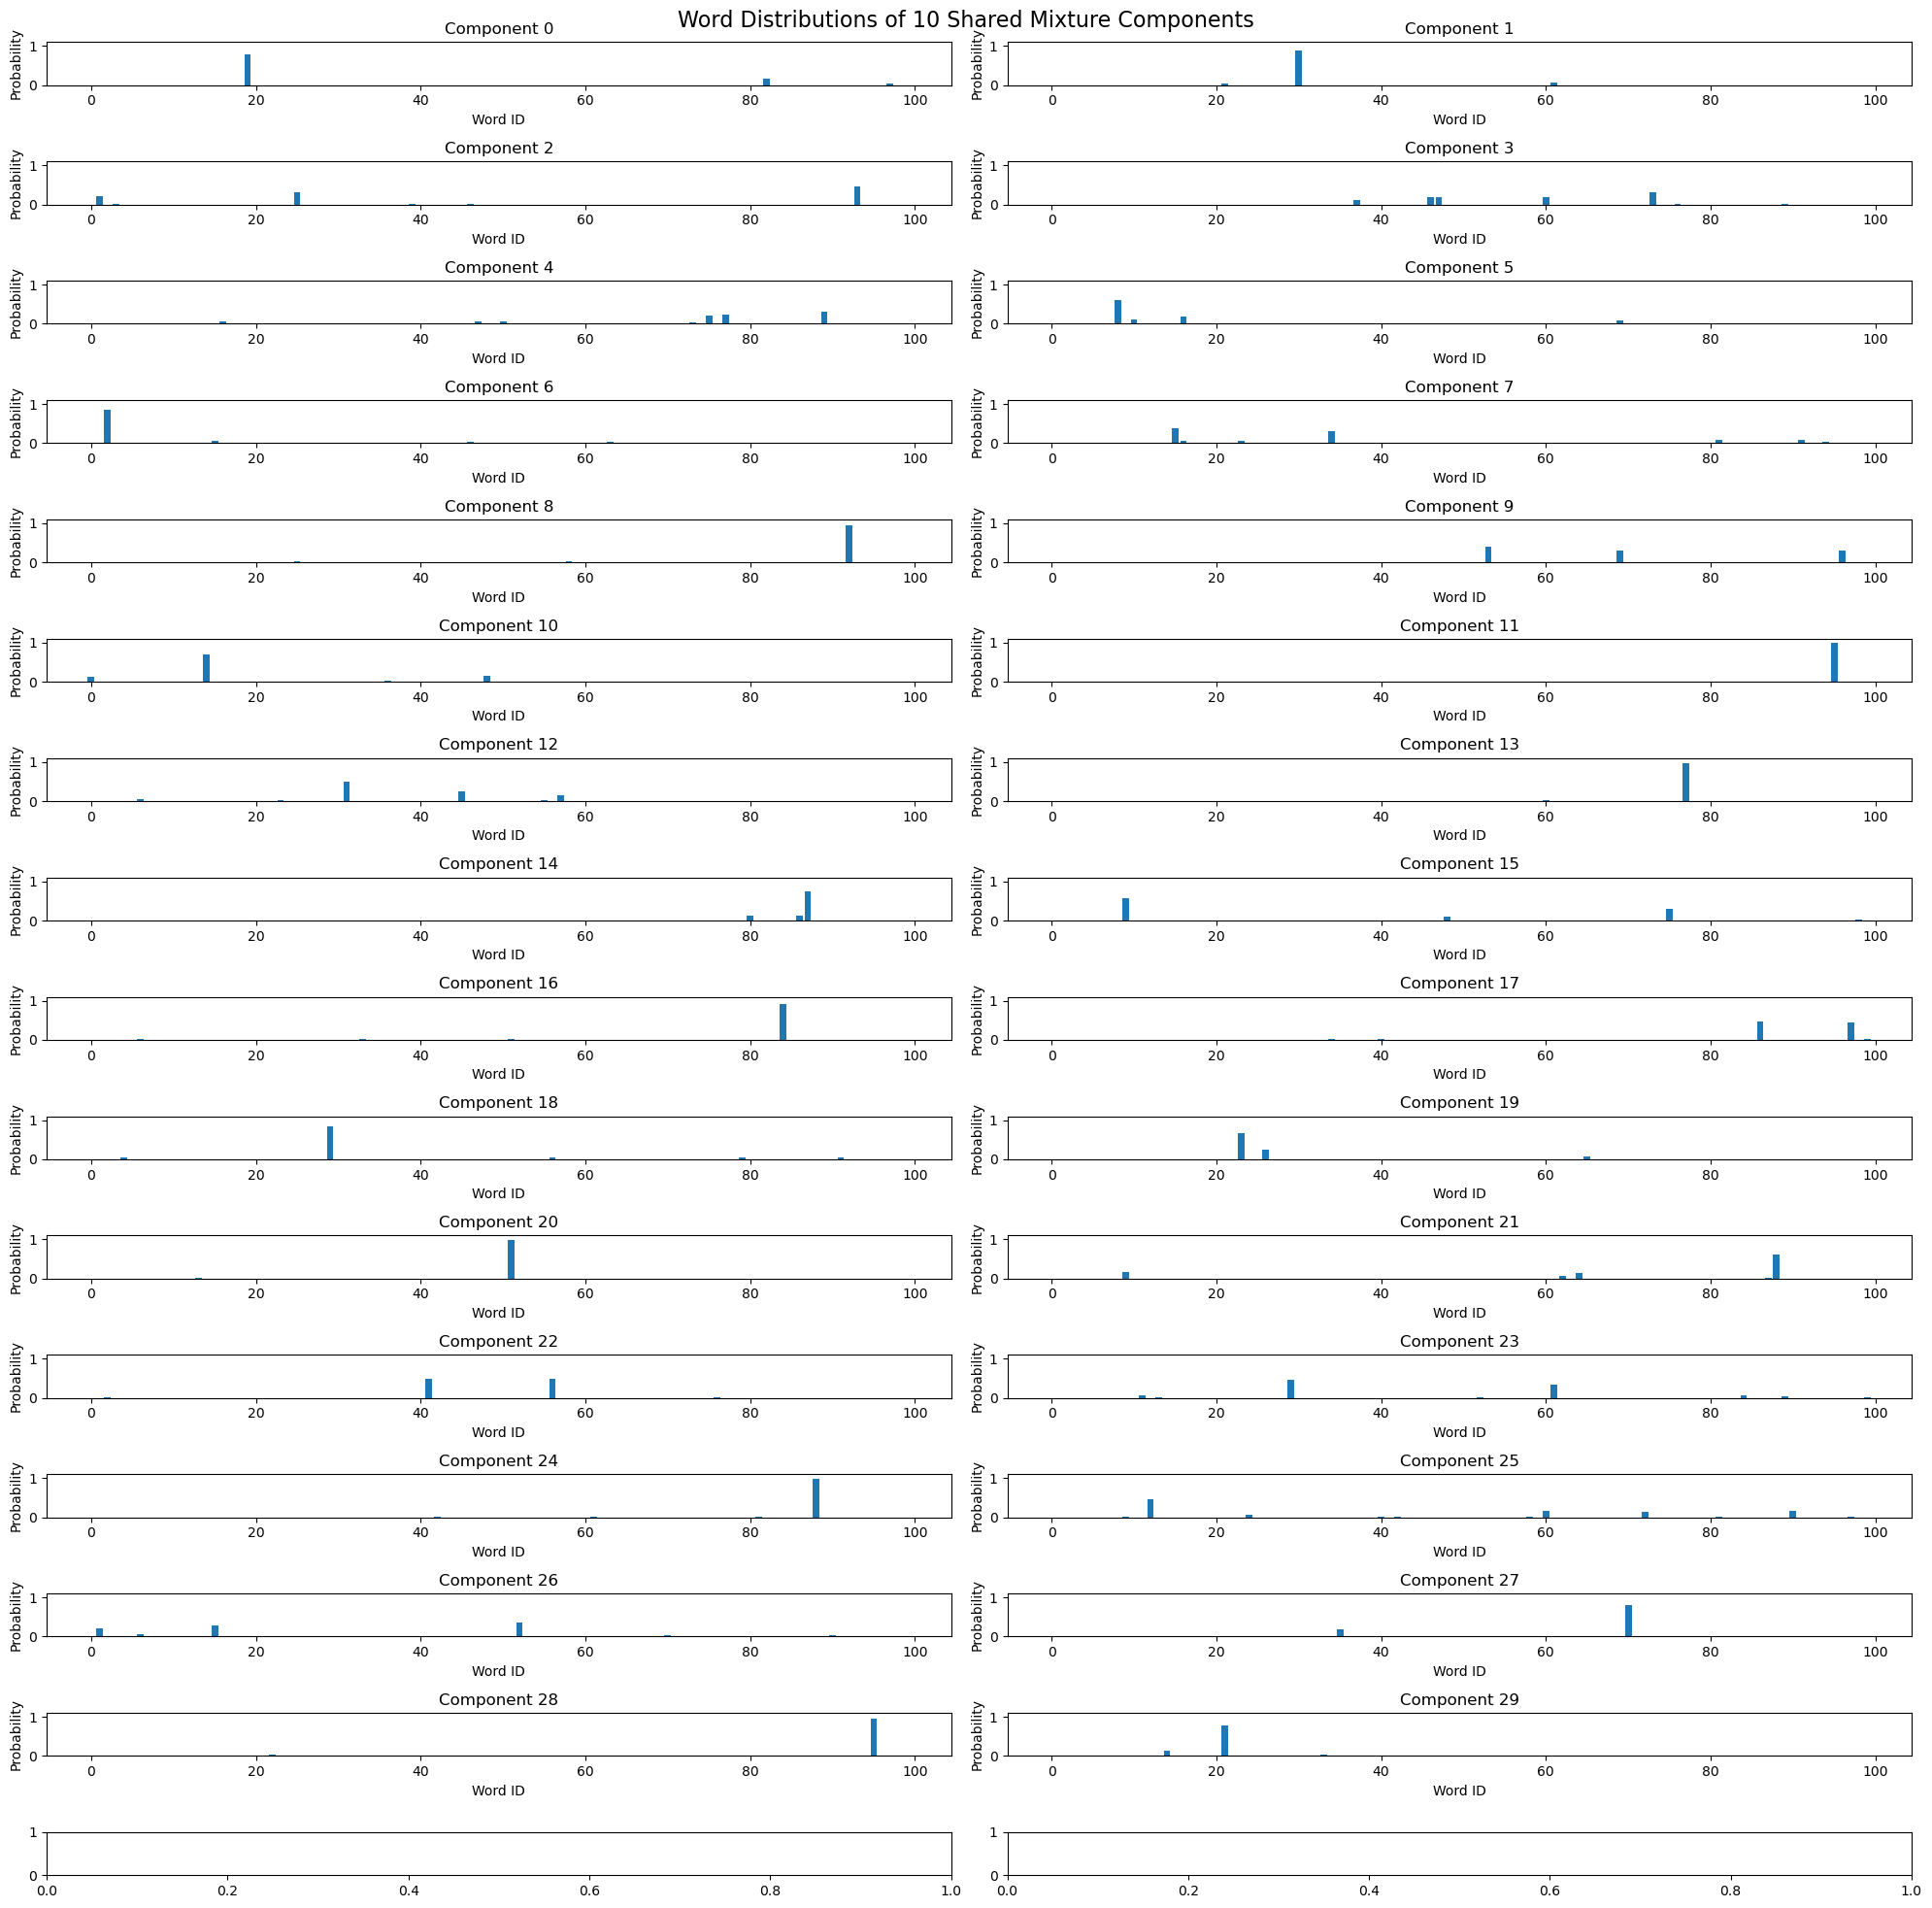

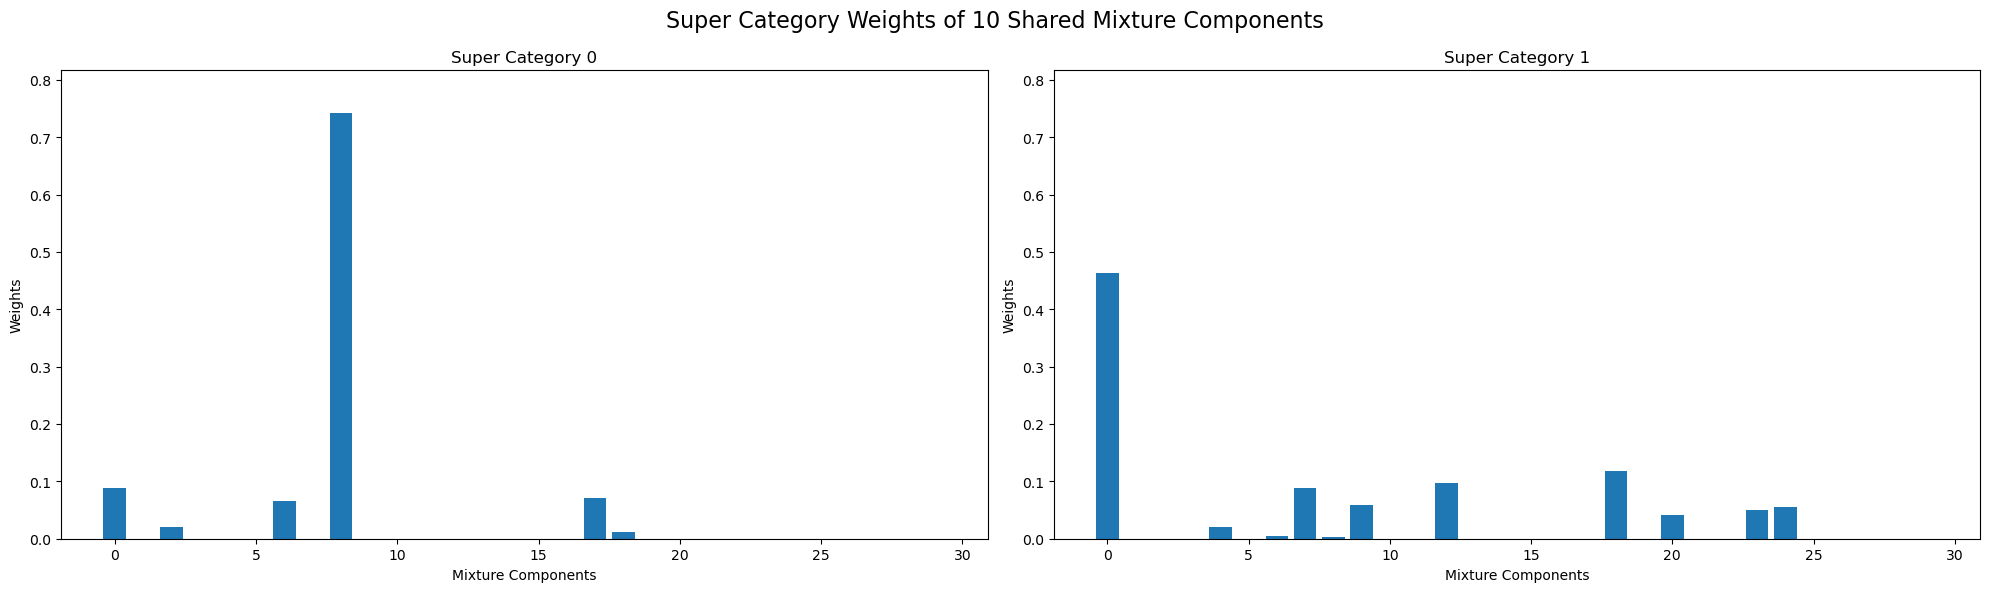

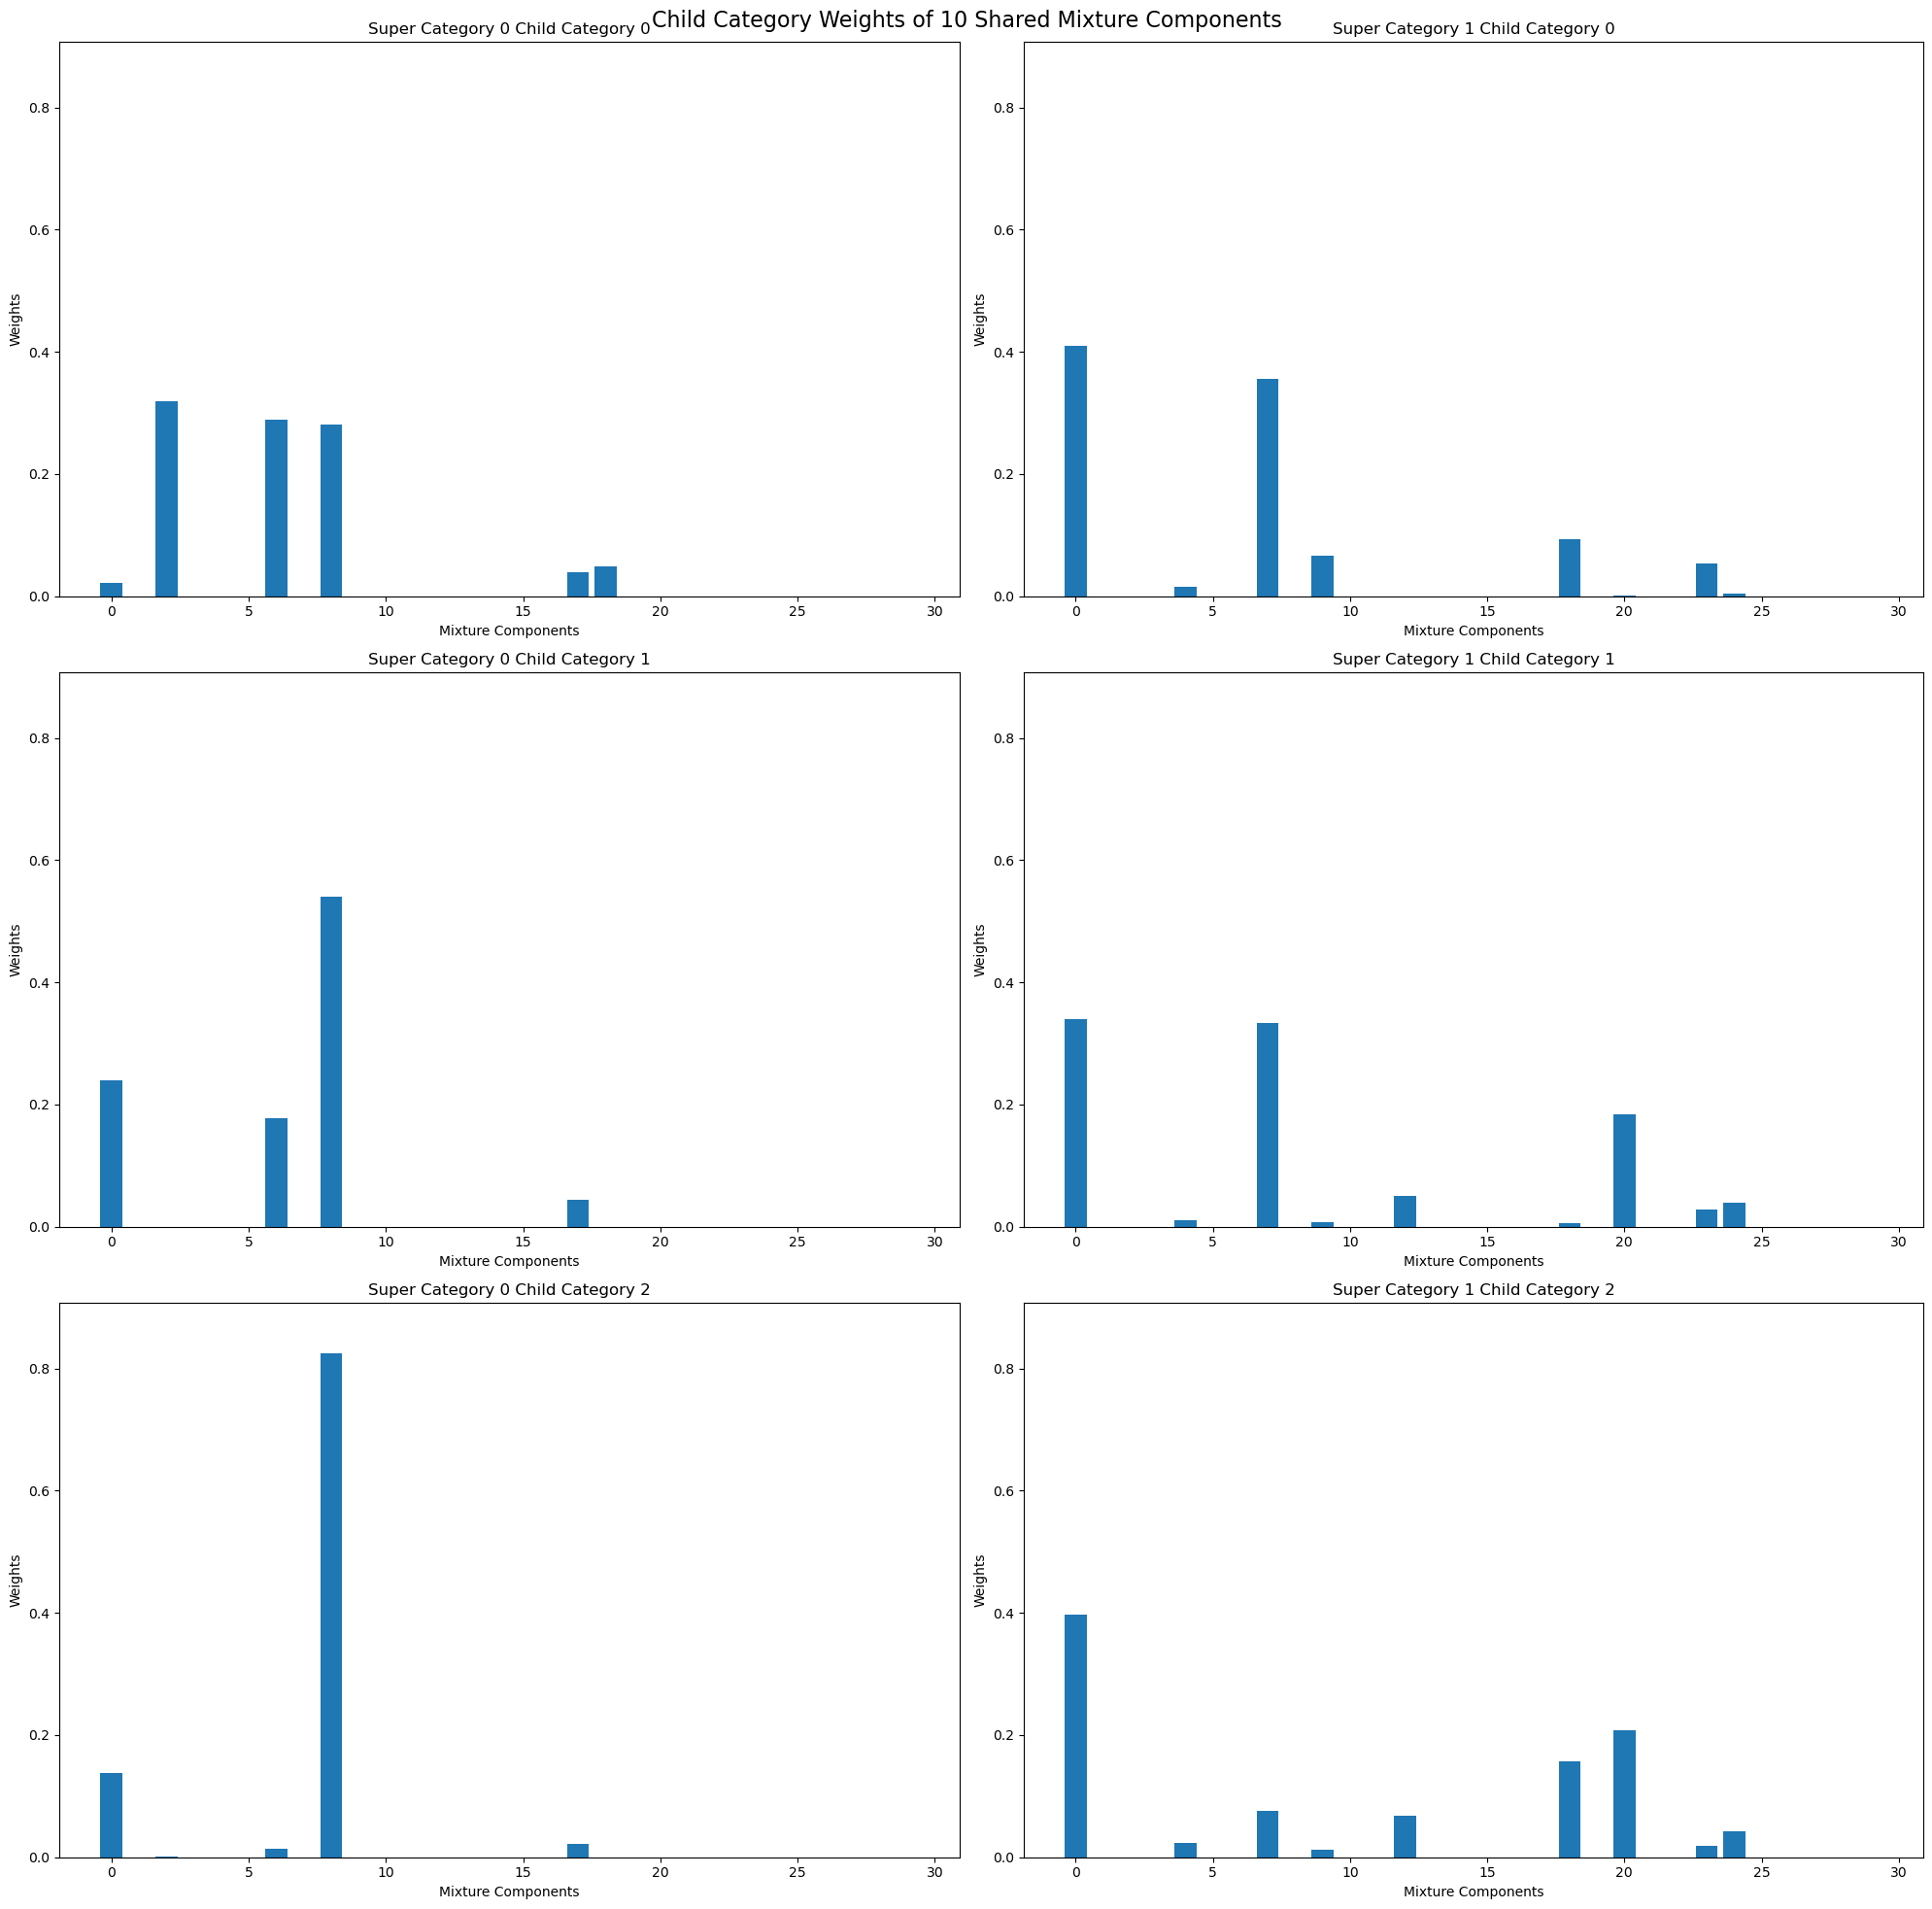

In [13]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = struct_upbd["G0"]
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
print(child_mix_weights.shape)

# Bar plots for each component
fig, axs = plt.subplots(int(num_components/2)+1, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i].numpy())
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
for i in range(2):
    ax = axs[i]
    ax.bar(range(num_components), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"], figsize=(20, 20))
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(num_components), child_mix_weights[i][j].numpy())
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()



🔁 Round 1 / 10
📌 Optimizing guide...


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 0, loss = 72044.81


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 100, loss = 66814.45
  [Guide] Step 200, loss = 69480.09
  [Guide] Step 300, loss = 68612.39
  [Guide] Step 400, loss = 60393.11
📌 Optimizing model...
  [Model] Step 0, loss = 61448.80
  [Model] Step 100, loss = 59556.16
  [Model] Step 200, loss = 54168.99
  [Model] Step 300, loss = 53492.24
  [Model] Step 400, loss = 51477.80

🔁 Round 2 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 46255.61
  [Guide] Step 100, loss = 54000.31
  [Guide] Step 200, loss = 49147.80
  [Guide] Step 300, loss = 51581.11
  [Guide] Step 400, loss = 47052.91
📌 Optimizing model...
  [Model] Step 0, loss = 49767.37
  [Model] Step 100, loss = 52932.63
  [Model] Step 200, loss = 39486.10
  [Model] Step 300, loss = 42425.75
  [Model] Step 400, loss = 42921.96

🔁 Round 3 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 47778.27
  [Guide] Step 100, loss = 40460.24
  [Guide] Step 200, loss = 45322.55
  [Guide] Step 300, loss = 36273.37
  [Guide] Step 400, loss = 36725.15
📌 Optimizing model...
  

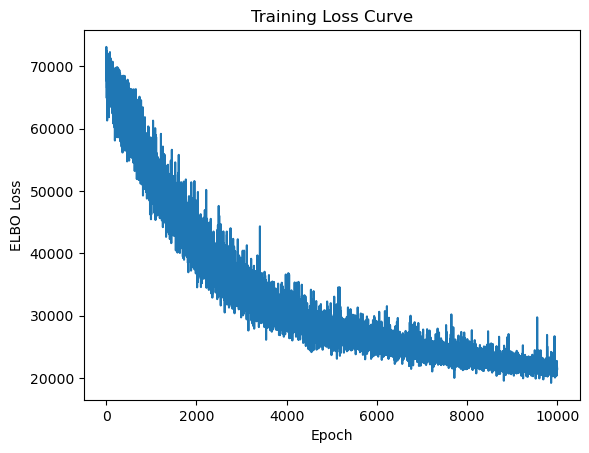

In [14]:
dataset = (data["x"], data["y"])
device = torch.device("cpu")
# Training settings
num_epochs = 1000
log_every = 100
lr = 1e-3

# Set up optimizer and ELBO
optim = pyro.optim.Adam({"lr": lr})

elbo = TraceEnum_ELBO(max_plate_nesting=1)
svi = SVI(model, guide, optim, loss=elbo)

# === Alternating training loop ===
num_rounds = 10
posterior_steps = 500
model_steps = 500
losses = []

for seed in range(0, 400, 100):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    # for epoch in range(num_epochs):
    #     pyro.clear_param_store()
    #     loss = svi.step(dataset, struct_upbd, vocab_size, device)
        
    #     losses.append(loss)
        
    #     if epoch % log_every == 0:
    #         print(f"Epoch {epoch:04d}  Loss: {loss:.4f}")
    #         optim.set_state({"lr": lr/(epoch+1)})
    for round_idx in range(num_rounds):
        print(f"\n🔁 Round {round_idx + 1} / {num_rounds}")
    
        # Phase 1: Guide (Posterior inference)
        set_requires_grad_by_prefix("model_", False)
        set_requires_grad_by_prefix("guide_", True)
        print("📌 Optimizing guide...")
        for step in range(posterior_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Guide] Step {step}, loss = {loss:.2f}")
    
        # Phase 2: Model (Generative parameter update)
        set_requires_grad_by_prefix("guide_", False)
        set_requires_grad_by_prefix("model_", True)
        print("📌 Optimizing model...")
        for step in range(model_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Model] Step {step}, loss = {loss:.2f}")
    # Optional: plot loss
    try:
        import matplotlib.pyplot as plt
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("ELBO Loss")
        plt.title("Training Loss Curve")
        plt.show()
    except ImportError:
        pass
    break



In [15]:
for name, value in pyro.get_param_store().items():
    print(f"{name}: {value}")


guide_beta_0_alpha: tensor([0.7721, 0.7476, 0.6890, 0.9113, 0.7523, 0.3700, 0.8317, 1.4641, 1.2170,
        1.3266, 0.4828, 0.8930, 0.2459, 0.2233, 0.4096, 0.7213, 0.8300, 0.6166,
        0.6462, 0.5079, 0.5621, 0.5680, 0.5594, 0.6670, 0.6305, 0.7631, 0.8467,
        0.1885, 0.7540, 0.8812], grad_fn=<AddBackward0>)
guide_beta_0_beta: tensor([ 5.3461, 17.4626,  2.5400,  3.0155,  2.8043,  1.3961,  3.0190,  3.9031,
         3.4234,  3.1366,  4.9693,  2.7243,  0.8106,  0.7528,  2.6112,  2.2703,
         2.0835,  2.7741,  1.5691,  2.5109,  2.8409,  2.5976,  2.3027,  2.1545,
         2.1535,  1.7340,  1.7548,  0.3703,  1.2284,  1.3518],
       grad_fn=<AddBackward0>)
guide_beta_1_alpha: tensor([1.2453e+00, 2.7344e-01, 2.2793e+00, 2.3040e+00, 1.2655e+00, 1.4717e+00,
        1.7667e+00, 1.8145e+00, 1.2469e+00, 1.8322e+00, 2.4958e-02, 9.7107e-01,
        1.3853e+00, 3.6878e-01, 2.5917e-02, 2.1319e-01, 3.5130e-01, 1.5173e-02,
        8.7168e-02, 7.5291e-05, 1.7394e-05, 7.0951e-06, 2.2037e-04, 7.

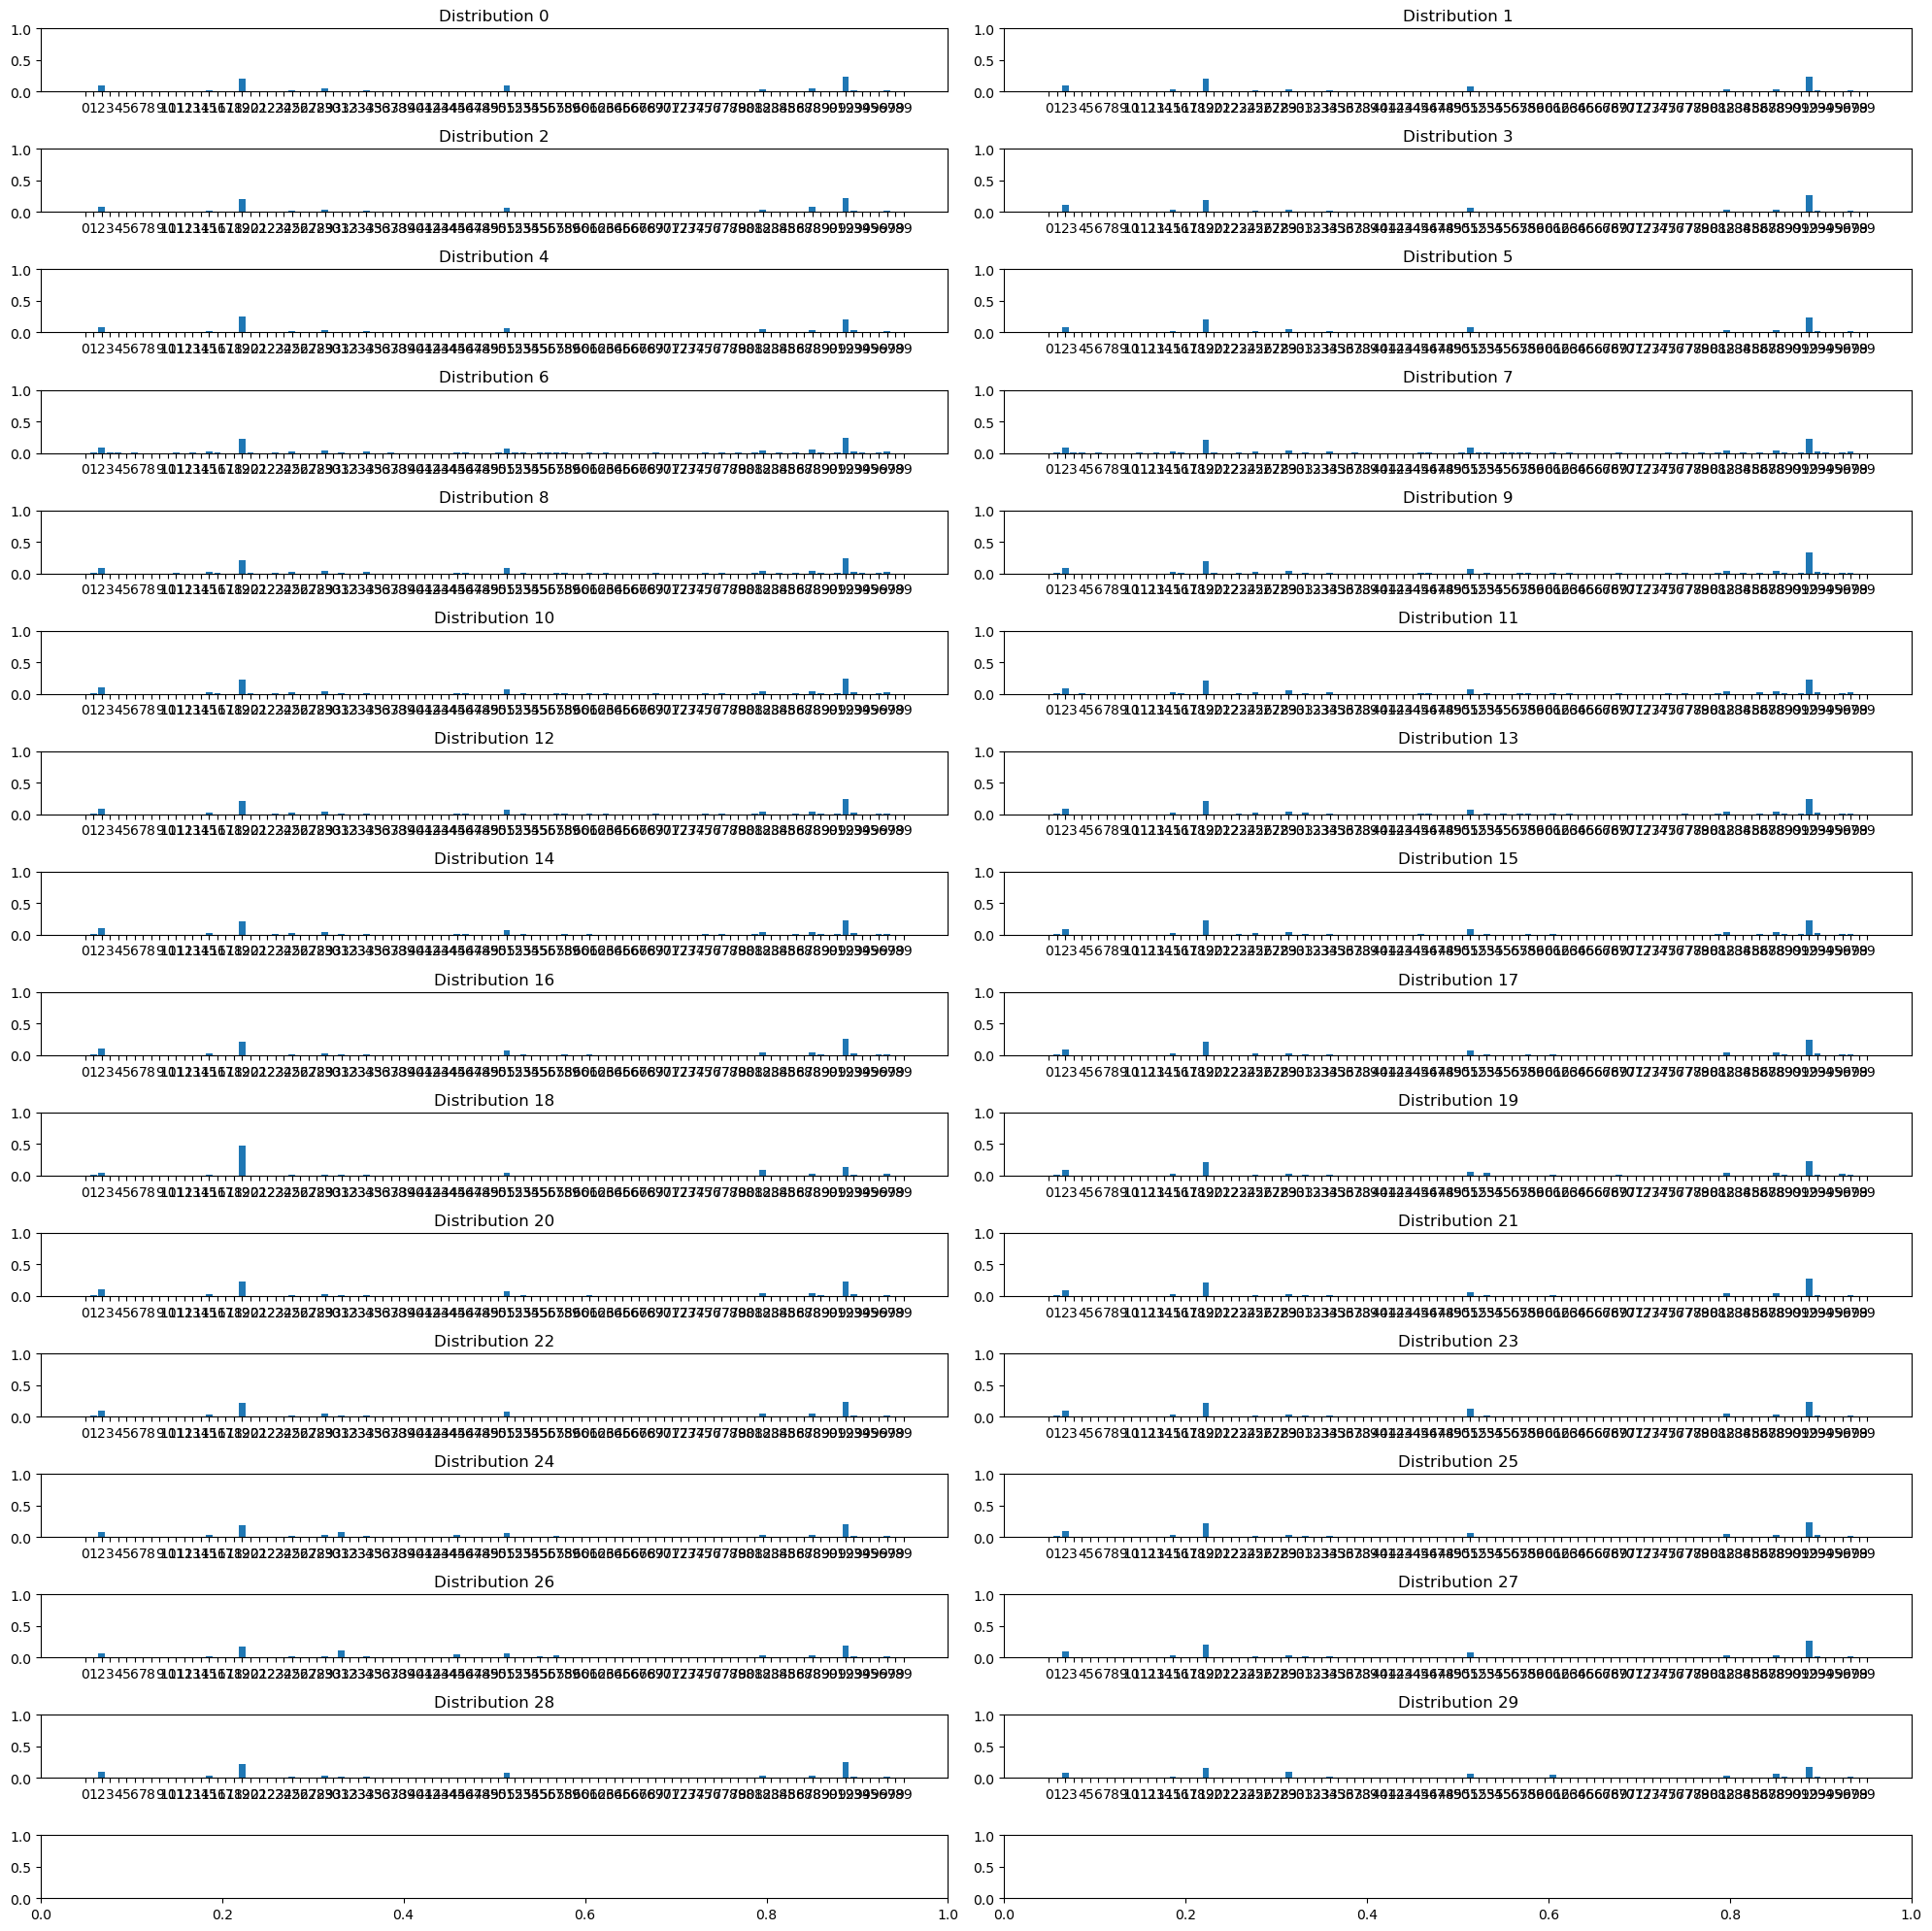

In [16]:
import torch
import matplotlib.pyplot as plt

# Example tensor: 10 distributions over 5 categories
params = pyro.get_param_store().get_param("model_phi_u").detach()

fig, axs = plt.subplots(int(struct_upbd["G0"]/2)+1, 2, figsize=(20, 20))

for i in range(struct_upbd["G0"]):
    ax = axs[i // 2, i % 2]
    ax.bar(range(params.size(1)), params[i].cpu().numpy())
    ax.set_title(f'Distribution {i}')
    ax.set_xticks(range(params.size(1)))
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


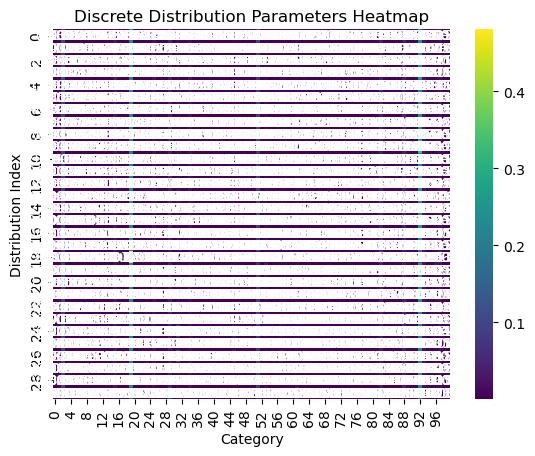

In [17]:
import seaborn as sns

sns.heatmap(params.numpy(), cmap='viridis', annot=True, cbar=True)
plt.xlabel("Category")
plt.ylabel("Distribution Index")
plt.title("Discrete Distribution Parameters Heatmap")
plt.show()


In [18]:
import torch
import torch.nn.functional as F

# Simulated inputs

true_params = data["word_dists"]
candidate_params = pyro.get_param_store().get_param("model_phi_u").detach()
print(true_params.shape)
print(candidate_params.shape)

# Normalize to make them valid distributions
true_params /= true_params.sum(dim=1, keepdim=True)
candidate_params /= candidate_params.sum(dim=1, keepdim=True)
assert torch.allclose(true_params.sum(dim=1), torch.ones_like(true_params.sum(dim=1)), atol=1e-4)
assert torch.allclose(candidate_params.sum(dim=1), torch.ones_like(candidate_params.sum(dim=1)), atol=1e-4)


# Compute Jensen-Shannon distance between all pairs
# def jensen_shannon(p, q, eps=1e-8):
#     # Normalize inputs to ensure valid distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)
#     m = 0.5 * (p + q)

#     # Compute KL divergences: kl_div expects log-prob as input
#     kl_pm = F.kl_div((p + eps).log(), m, reduction='none').sum(-1)
#     kl_qm = F.kl_div((q + eps).log(), m, reduction='none').sum(-1)

#     return 0.5 * (kl_pm + kl_qm)
def jensen_shannon(p, q, eps=1e-8):
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)
    m = 0.5 * (p + q)

    kl_pm = (p * ((p + eps).log() - (m + eps).log())).sum(-1)
    kl_qm = (q * ((q + eps).log() - (m + eps).log())).sum(-1)

    return 0.5 * (kl_pm + kl_qm)
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)


torch.Size([30, 100])
torch.Size([30, 100])
tensor([[0.6366, 0.6286, 0.6363, 0.6123, 0.6719, 0.6374, 0.6433, 0.6400, 0.6401,
         0.6128, 0.6449, 0.6381, 0.6387, 0.6392, 0.6388, 0.6481, 0.6320, 0.6416,
         0.8406, 0.6324, 0.6463, 0.6313, 0.6382, 0.6348, 0.6125, 0.6344, 0.5996,
         0.6302, 0.6324, 0.5778],
        [0.3217, 0.3267, 0.3266, 0.3206, 0.3210, 0.3250, 0.3225, 0.3222, 0.3221,
         0.3221, 0.3218, 0.3214, 0.3225, 0.3216, 0.3224, 0.3225, 0.3211, 0.3217,
         0.3164, 0.3219, 0.3225, 0.3251, 0.3226, 0.3232, 0.3241, 0.3281, 0.3222,
         0.3222, 0.3221, 0.3538],
        [0.4196, 0.4164, 0.4177, 0.4139, 0.4471, 0.4208, 0.4212, 0.4206, 0.4215,
         0.4159, 0.4351, 0.4189, 0.4232, 0.4195, 0.4351, 0.4242, 0.4193, 0.4343,
         0.3918, 0.4153, 0.4315, 0.4177, 0.4224, 0.4204, 0.4109, 0.4316, 0.4108,
         0.4180, 0.4204, 0.3903],
        [0.3265, 0.3347, 0.3259, 0.3270, 0.3282, 0.3259, 0.3272, 0.3266, 0.3257,
         0.3248, 0.3276, 0.3264, 0.3277, 0.3

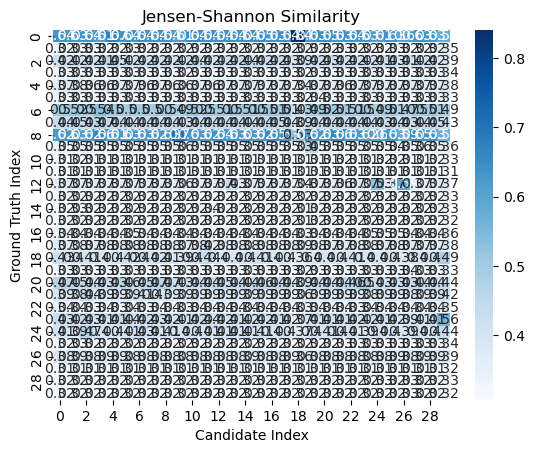

In [19]:
# import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()


In [20]:
# # Initialize parameters
param_dims = list(struct_upbd.values())
param_dims.reverse()

struct_params = {}
# dimension: number of mixture
struct_params["alpha0"] = pyro.get_param_store().get_param("model_alpha0").detach()
# dimension: number of mixture
struct_params["alpha1"] = pyro.get_param_store().get_param("model_alpha1").detach()

for i in range(2, len(struct_upbd)+1, 1):
    # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
    struct_params[f"alpha{i}"] = pyro.get_param_store().get_param(f"model_alpha{i}").detach().unsqueeze(-1)
# dimension: number of mixture * vocabulary size
gen_params = pyro.get_param_store().get_param("model_phi_u").detach()
# dimension: number of mixture * 1
reg_params_mu = pyro.get_param_store().get_param("model_phi_y_mu").detach()
# dimension: number of mixture * 1
reg_params_sigma = pyro.get_param_store().get_param("model_phi_y_sigma").detach()

struct_weights = {}
# dimension: number of mixture
beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
# dimension: number of mixture
struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
for level in range(1, len(struct_upbd), 1):
    # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
    param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
    param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
    with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
    # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
    struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

assign_prior = {}
# dimension: number of level - 1
etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
for level in range(1, len(struct_upbd), 1):
    params_shape = param_dims[-level-1:-1]
    params_shape.reverse()
    # dimension: level 1 category * level 2 category * ... * level level category
    assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

In [21]:
struct_weights

{'G0': tensor([6.5921e-01, 4.3946e-02, 6.5995e-02, 6.9302e-02, 2.1498e-02, 5.2880e-02,
         4.1257e-03, 3.4200e-02, 8.1867e-03, 7.5902e-03, 1.1301e-02, 1.1295e-02,
         9.2301e-04, 1.1925e-03, 6.5083e-03, 3.6203e-04, 6.2502e-04, 2.2549e-04,
         9.2410e-05, 2.9521e-05, 3.0936e-04, 1.0000e-06, 1.2921e-05, 2.9145e-05,
         4.1067e-06, 2.2847e-05, 2.1359e-06, 3.8365e-05, 2.0784e-05, 4.5266e-05]),
 'G1': tensor([[7.9794e-01, 5.4653e-04, 3.6831e-02, 8.6979e-02, 1.0736e-02, 6.5992e-02,
          4.3874e-06, 8.2500e-05, 6.1155e-04, 1.8062e-04, 7.5684e-05, 9.9998e-07,
          9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07,
          9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07,
          9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07, 9.9998e-07],
         [6.8084e-01, 1.0224e-03, 1.3742e-01, 1.0603e-01, 5.3340e-03, 5.3002e-02,
          9.9998e-07, 1.5028e-02, 4.7524e-05, 1.4337e-05, 4.4966e-04, 5.3327e-04,
      

In [25]:
print(struct_weights["G2"].shape)
selected = struct_weights["G2"].view(-1, struct_upbd["G0"])
print(selected.shape)

torch.Size([3, 2, 30])
torch.Size([6, 30])


In [26]:
selected = selected/selected.sum(dim=-1, keepdim=True)

In [27]:
selected.shape

torch.Size([6, 30])

tensor([[0.3709, 0.5377, 0.4511, 0.4497, 0.4605, 0.3899],
        [0.7102, 0.7026, 0.7085, 0.6501, 0.7103, 0.6797],
        [0.5962, 0.5826, 0.5966, 0.5584, 0.5928, 0.5494],
        [0.6675, 0.6627, 0.6661, 0.6160, 0.6674, 0.6439],
        [0.5100, 0.5047, 0.5132, 0.4890, 0.5101, 0.4824],
        [0.7025, 0.6916, 0.7009, 0.6437, 0.7037, 0.6681]])


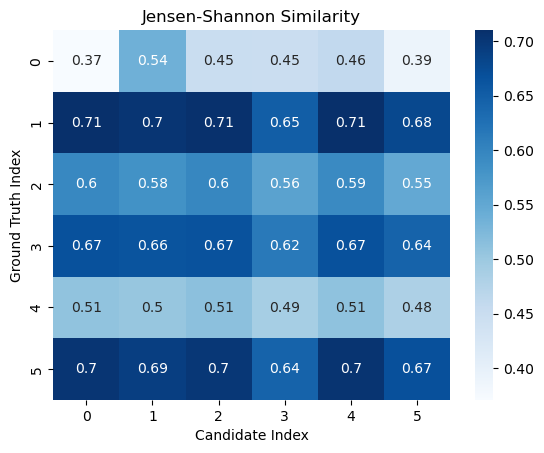

In [29]:
true_params = data["child_mix_weights"].view(-1, struct_upbd["G0"])
candidate_params = selected

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [ ]:
true_params = data["child_mix_weights"].view(-1, 10)
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [ ]:
from pyro.infer import Predictive

# guide: your trained guide
# model: your model without obs
# num_samples: number of predictive samples

predictive = Predictive(model, guide=guide, num_samples=1000)

# Omit `data` or provide partial input depending on your model
samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)  # or data=..., depending on your model's inputs

In [ ]:
predict = samples['y'].mean(dim=0)
predict_var = samples['y'].var(dim=0)

In [ ]:
y_true = dataset[1]     # ground truth
y_pred = predict # predicted (with noise)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y = x line
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# Example data
N=120
mean_pred = y_pred
var_pred = predict_var

std_pred = var_pred.sqrt()
x = torch.arange(N)

plt.figure(figsize=(12, 5))

# Confidence interval (±1 std)
plt.fill_between(x, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.3, label="±1 Std Dev")

# Prediction mean
plt.plot(x, mean_pred, color="orange", label="Predicted Mean")

# Ground truth
plt.plot(x, y_true, color="blue", linestyle="--", label="Ground Truth")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Prediction vs Ground Truth with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()